# Analiza wyników — GQA (Lista 12)

In [1]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('./mlruns')

COLORS = {'MHA': '#2ecc71', 'GQA': '#3498db', 'MQA': '#e74c3c', 'DynamicGQA': '#e67e22'}
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

def load_exp(name):
    exp = mlflow.get_experiment_by_name(name)
    df = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format='pandas')
    df.columns = [
        'run_name' if c == 'tags.mlflow.runName'
        else c.replace('params.', '').replace('metrics.', '').replace('tags.', '')
        for c in df.columns
    ]
    df = df[df['status'] == 'FINISHED'].copy()
    for col in ['num_heads', 'num_groups', 'seed', 'num_params', 'max_length']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_imdb = load_exp('GQA_IMDB')
df_ins  = load_exp('GQA_InsectWingbeat')
print(f'IMDB ukończone runy:    {len(df_imdb)}')
print(f'InsectWingbeat ukończone: {len(df_ins)}')

IMDB ukończone runy:    59
InsectWingbeat ukończone: 33


---
## IMDB — Eksperyment 1: Siatka H×G

In [2]:
exp1 = df_imdb[df_imdb['run_name'].str.startswith('grid_')].copy()

grid = exp1.groupby(['num_heads', 'num_groups', 'attention_type']).agg(
    acc  = ('best_test_acc', 'mean'),
    ovft = ('overfitting_gap', 'mean'),
    params = ('num_params', 'first'),
).reset_index()

print(grid[['num_heads','num_groups','attention_type','acc','ovft','params']]
      .sort_values('acc', ascending=False).to_string(index=False))

 num_heads  num_groups attention_type      acc     ovft  params
         4           1            MQA 0.838480 0.089480 1840706
         2           2            MHA 0.837920 0.094333 1914434
         1           1            MHA 0.837080 0.091480 1914434
         8           2            GQA 0.836920 0.093827 1840706
         8           1            MQA 0.836507 0.089387 1828418
         4           2            GQA 0.836387 0.096547 1865282
         2           1            MQA 0.835960 0.093293 1865282
         4           4            MHA 0.834827 0.103133 1914434
         8           4            GQA 0.833480 0.105640 1865282
         8           8            MHA 0.832693 0.112053 1914434


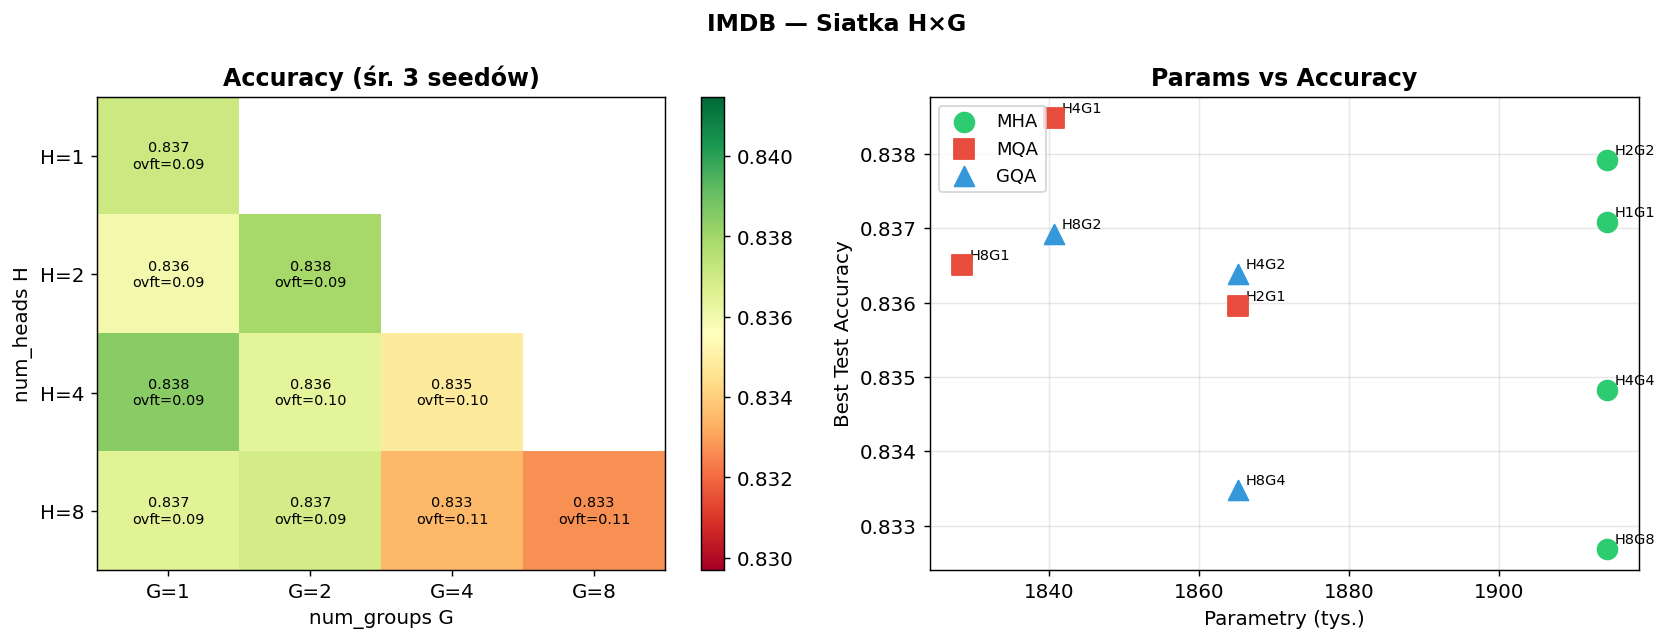

In [3]:
H_vals = sorted(exp1['num_heads'].dropna().unique().astype(int))
G_vals = sorted(exp1['num_groups'].dropna().unique().astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- 1. Heatmapa accuracy ---
mat_acc  = np.full((len(H_vals), len(G_vals)), np.nan)
mat_ovft = np.full((len(H_vals), len(G_vals)), np.nan)

for _, row in grid.iterrows():
    i = H_vals.index(int(row.num_heads))
    j = G_vals.index(int(row.num_groups))
    mat_acc[i, j]  = row.acc
    mat_ovft[i, j] = row.ovft

vmin, vmax = np.nanmin(mat_acc) - 0.003, np.nanmax(mat_acc) + 0.003
im = ax1.imshow(mat_acc, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
ax1.set_xticks(range(len(G_vals))); ax1.set_xticklabels([f'G={g}' for g in G_vals])
ax1.set_yticks(range(len(H_vals))); ax1.set_yticklabels([f'H={h}' for h in H_vals])
ax1.set_title('Accuracy (śr. 3 seedów)', fontweight='bold')
ax1.set_xlabel('num_groups G'); ax1.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax1, format='%.3f')

for i in range(len(H_vals)):
    for j in range(len(G_vals)):
        v = mat_acc[i, j]
        if not np.isnan(v):
            rel = (v - vmin) / (vmax - vmin)
            clr = 'black' if 0.25 < rel < 0.75 else 'white'
            # overfitting gap jako małe podpisy
            ovft_str = f'\novft={mat_ovft[i,j]:.2f}' if not np.isnan(mat_ovft[i,j]) else ''
            ax1.text(j, i, f'{v:.3f}{ovft_str}', ha='center', va='center',
                     fontsize=8, color=clr)

# --- 2. Parametry vs Accuracy ---
for _, row in grid.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax2.scatter(row.params / 1000, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax2.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.params / 1000, row.acc),
                 xytext=(4, 3), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Parametry (tys.)')
ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3)

# legenda bez duplikatów
handles, labels = ax2.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax2.legend(uniq_h, uniq_l, fontsize=10)

plt.suptitle('IMDB — Siatka H×G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_exp1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## IMDB — Eksperyment 2: Długość sekwencji × G

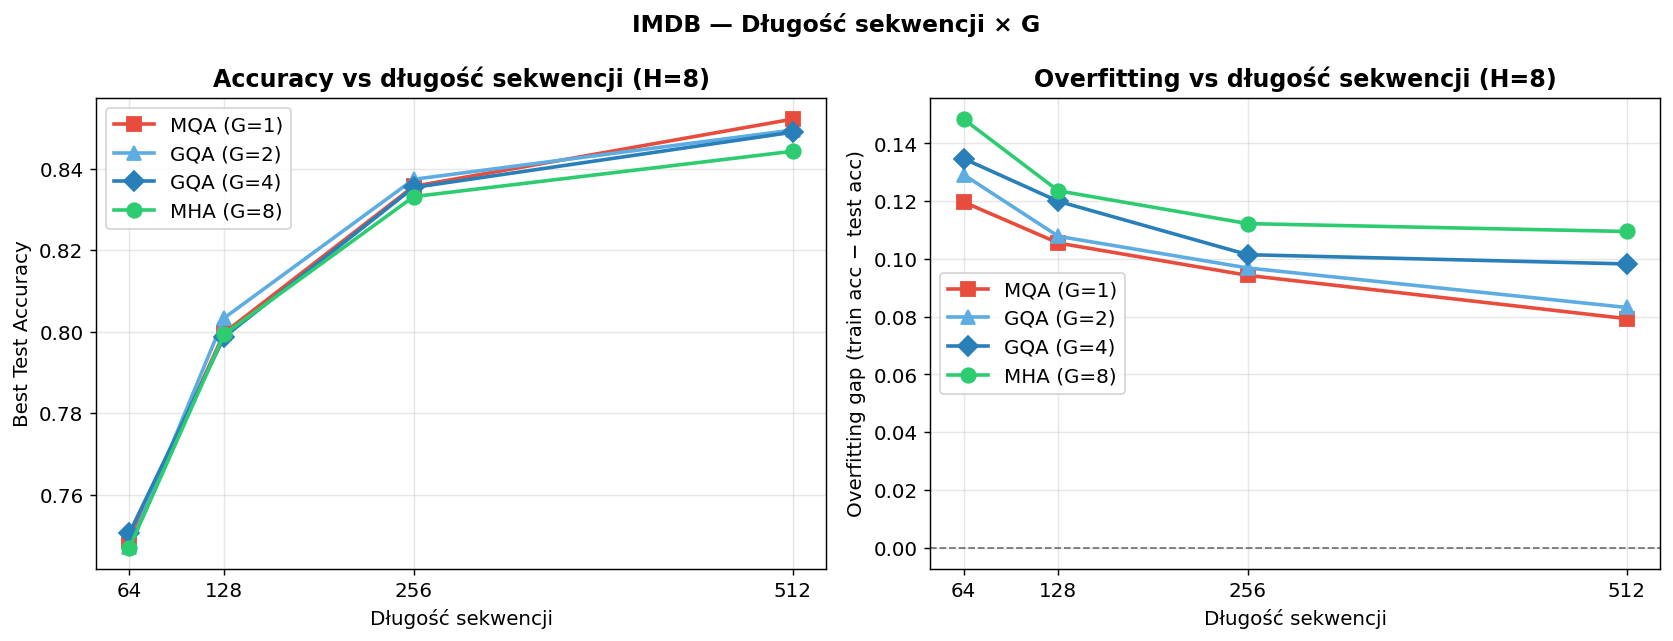

In [4]:
exp2 = df_imdb[df_imdb['run_name'].str.startswith('exp2_')].copy()

lengths = sorted(exp2['max_length'].dropna().unique().astype(int))
G_exp2  = sorted(exp2['num_groups'].dropna().unique().astype(int))

g_labels = {1: 'MQA (G=1)', 2: 'GQA (G=2)', 4: 'GQA (G=4)', 8: 'MHA (G=8)'}
g_colors = {1: COLORS['MQA'], 2: '#5dade2', 4: '#2980b9', 8: COLORS['MHA']}
g_markers = {1: 's', 2: '^', 4: 'D', 8: 'o'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- 1. Accuracy vs długość sekwencji ---
for G in G_exp2:
    accs = [exp2[(exp2['max_length'] == L) & (exp2['num_groups'] == G)]['best_test_acc'].mean()
            for L in lengths]
    ax1.plot(lengths, accs,
             marker=g_markers[G], color=g_colors[G], linewidth=2, markersize=8,
             label=g_labels[G])

ax1.set_xlabel('Długość sekwencji')
ax1.set_ylabel('Best Test Accuracy')
ax1.set_title('Accuracy vs długość sekwencji (H=8)', fontweight='bold')
ax1.set_xticks(lengths)
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- 2. Overfitting gap vs długość sekwencji ---
for G in G_exp2:
    ovfts = [exp2[(exp2['max_length'] == L) & (exp2['num_groups'] == G)]['overfitting_gap'].mean()
             for L in lengths]
    ax2.plot(lengths, ovfts,
             marker=g_markers[G], color=g_colors[G], linewidth=2, markersize=8,
             label=g_labels[G])

ax2.set_xlabel('Długość sekwencji')
ax2.set_ylabel('Overfitting gap (train acc − test acc)')
ax2.set_title('Overfitting vs długość sekwencji (H=8)', fontweight='bold')
ax2.set_xticks(lengths)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('IMDB — Długość sekwencji × G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_imdb_exp2.png', dpi=150, bbox_inches='tight')
plt.show()

---
## InsectWingbeat — Eksperyment 1: Siatka H×G

In [5]:
ins_grid = df_ins[df_ins['run_name'].str.startswith('grid_')].copy()

ins_summary = ins_grid.groupby(['num_heads', 'num_groups', 'attention_type']).agg(
    acc    = ('best_test_acc', 'mean'),
    ovft   = ('overfitting_gap', 'mean'),
    params = ('num_params', 'first'),
).reset_index()

print(ins_summary[['num_heads','num_groups','attention_type','acc','ovft','params']]
      .sort_values('acc', ascending=False).to_string(index=False))

 num_heads  num_groups attention_type      acc      ovft  params
         8           8            MHA 0.670667 -0.010583  165994
         8           4            GQA 0.657567 -0.016050  153706
         8           2            GQA 0.656033 -0.018675  147562
         4           4            MHA 0.651200 -0.011175  165994
         4           2            GQA 0.649200 -0.011150  153706
         2           2            MHA 0.645833 -0.015358  165994
         2           1            MQA 0.644067 -0.015900  153706
         8           1            MQA 0.643667 -0.016633  144490
         4           1            MQA 0.641933 -0.021583  147562
         1           1            MHA 0.639600 -0.011508  165994


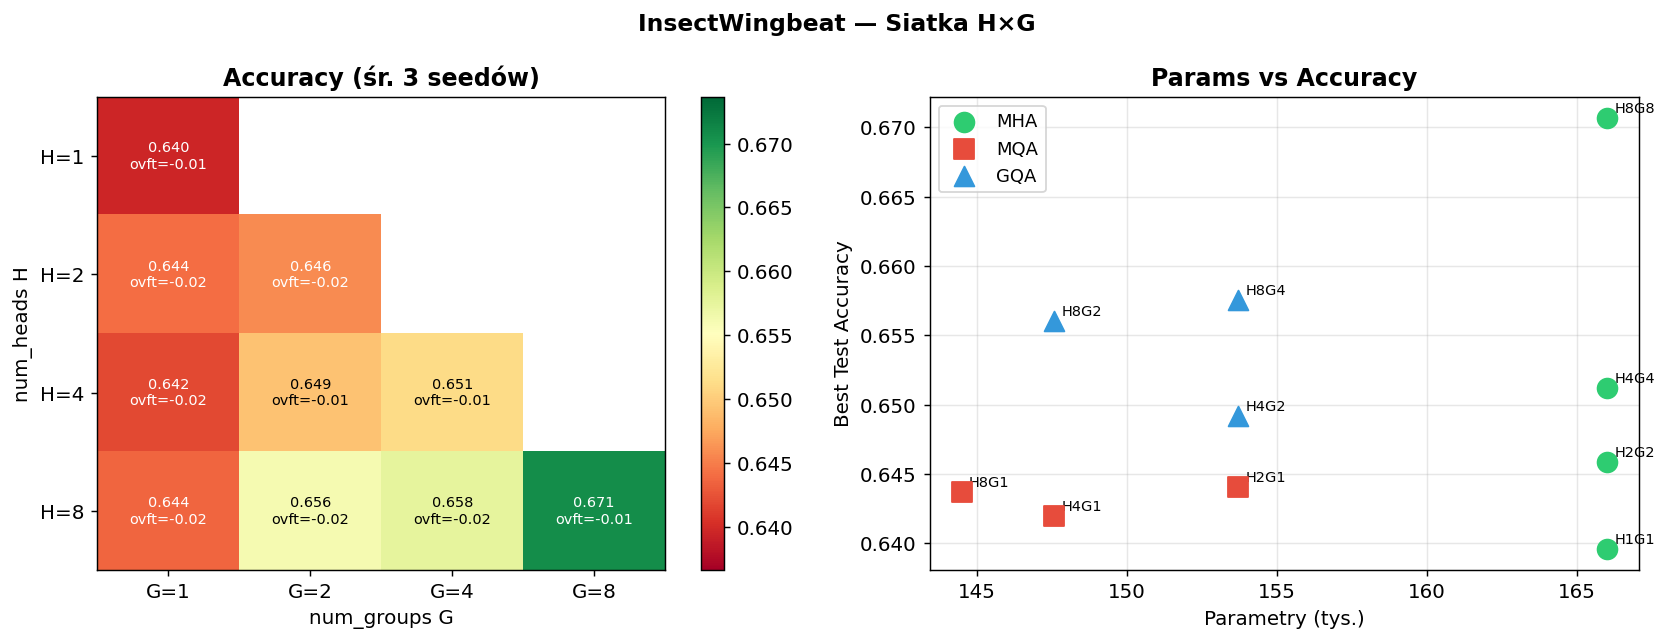

In [6]:
H_vals_i = sorted(ins_grid['num_heads'].dropna().unique().astype(int))
G_vals_i = sorted(ins_grid['num_groups'].dropna().unique().astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- 1. Heatmapa accuracy ---
mat_i      = np.full((len(H_vals_i), len(G_vals_i)), np.nan)
mat_ovft_i = np.full((len(H_vals_i), len(G_vals_i)), np.nan)

for _, row in ins_summary.iterrows():
    i = H_vals_i.index(int(row.num_heads))
    j = G_vals_i.index(int(row.num_groups))
    mat_i[i, j]      = row.acc
    mat_ovft_i[i, j] = row.ovft

vmin_i, vmax_i = np.nanmin(mat_i) - 0.003, np.nanmax(mat_i) + 0.003
im = ax1.imshow(mat_i, cmap='RdYlGn', vmin=vmin_i, vmax=vmax_i, aspect='auto')
ax1.set_xticks(range(len(G_vals_i))); ax1.set_xticklabels([f'G={g}' for g in G_vals_i])
ax1.set_yticks(range(len(H_vals_i))); ax1.set_yticklabels([f'H={h}' for h in H_vals_i])
ax1.set_title('Accuracy (śr. 3 seedów)', fontweight='bold')
ax1.set_xlabel('num_groups G'); ax1.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax1, format='%.3f')

for i in range(len(H_vals_i)):
    for j in range(len(G_vals_i)):
        v = mat_i[i, j]
        if not np.isnan(v):
            rel = (v - vmin_i) / (vmax_i - vmin_i)
            clr = 'black' if 0.25 < rel < 0.75 else 'white'
            ovft_str = f'\novft={mat_ovft_i[i,j]:.2f}' if not np.isnan(mat_ovft_i[i,j]) else ''
            ax1.text(j, i, f'{v:.3f}{ovft_str}', ha='center', va='center', fontsize=8, color=clr)

# --- 2. Parametry vs Accuracy ---
for _, row in ins_summary.iterrows():
    at = row.attention_type
    marker = 'o' if at == 'MHA' else ('s' if at == 'MQA' else '^')
    ax2.scatter(row.params / 1000, row.acc, s=120, marker=marker,
                color=COLORS.get(at, 'gray'), zorder=5, label=at)
    ax2.annotate(f'H{int(row.num_heads)}G{int(row.num_groups)}',
                 (row.params / 1000, row.acc),
                 xytext=(4, 3), textcoords='offset points', fontsize=8)

ax2.set_xlabel('Parametry (tys.)')
ax2.set_ylabel('Best Test Accuracy')
ax2.set_title('Params vs Accuracy', fontweight='bold')
ax2.grid(True, alpha=0.3)

handles, labels = ax2.get_legend_handles_labels()
seen = {}; uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True; uniq_h.append(h); uniq_l.append(l)
ax2.legend(uniq_h, uniq_l, fontsize=10)

plt.suptitle('InsectWingbeat — Siatka H×G', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wyniki_insect_exp1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## InsectWingbeat — Eksperyment 2: Naive GQA vs Dynamic GQA

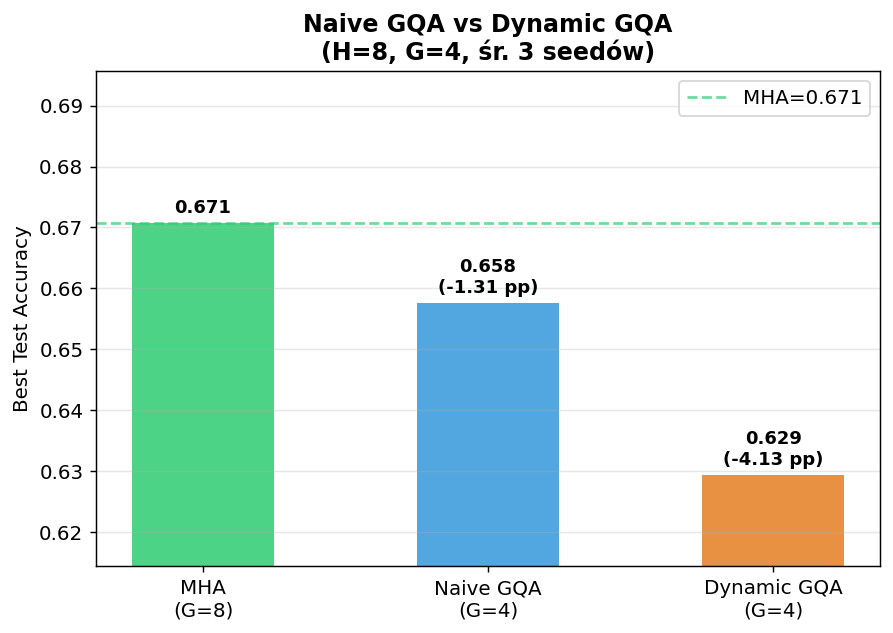

In [7]:
dyn       = df_ins[df_ins['run_name'].str.startswith('dynamic_')].copy()
naive_h8g4 = ins_grid[(ins_grid['num_heads'] == 8) & (ins_grid['num_groups'] == 4)].copy()
mha_h8g8   = ins_grid[(ins_grid['num_heads'] == 8) & (ins_grid['num_groups'] == 8)].copy()

labels = ['MHA\n(G=8)', 'Naive GQA\n(G=4)', 'Dynamic GQA\n(G=4)']
means  = [mha_h8g8['best_test_acc'].mean(),
           naive_h8g4['best_test_acc'].mean(),
           dyn['best_test_acc'].mean()]
colors = [COLORS['MHA'], COLORS['GQA'], COLORS['DynamicGQA']]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, means, color=colors, alpha=0.85, width=0.5)
ax.axhline(means[0], color=COLORS['MHA'], linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'MHA={means[0]:.3f}')

for bar, m, src in zip(bars, means, [mha_h8g8, naive_h8g4, dyn]):
    gap = (m - means[0]) * 100
    label = f'{m:.3f}' if gap == 0 else f'{m:.3f}\n({gap:+.2f} pp)'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            label, ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Best Test Accuracy')
ax.set_title('Naive GQA vs Dynamic GQA\n(H=8, G=4, śr. 3 seedów)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
ax.set_ylim(min(means) - 0.015, max(means) + 0.025)

plt.tight_layout()
plt.savefig('wyniki_insect_exp2.png', dpi=150, bbox_inches='tight')
plt.show()